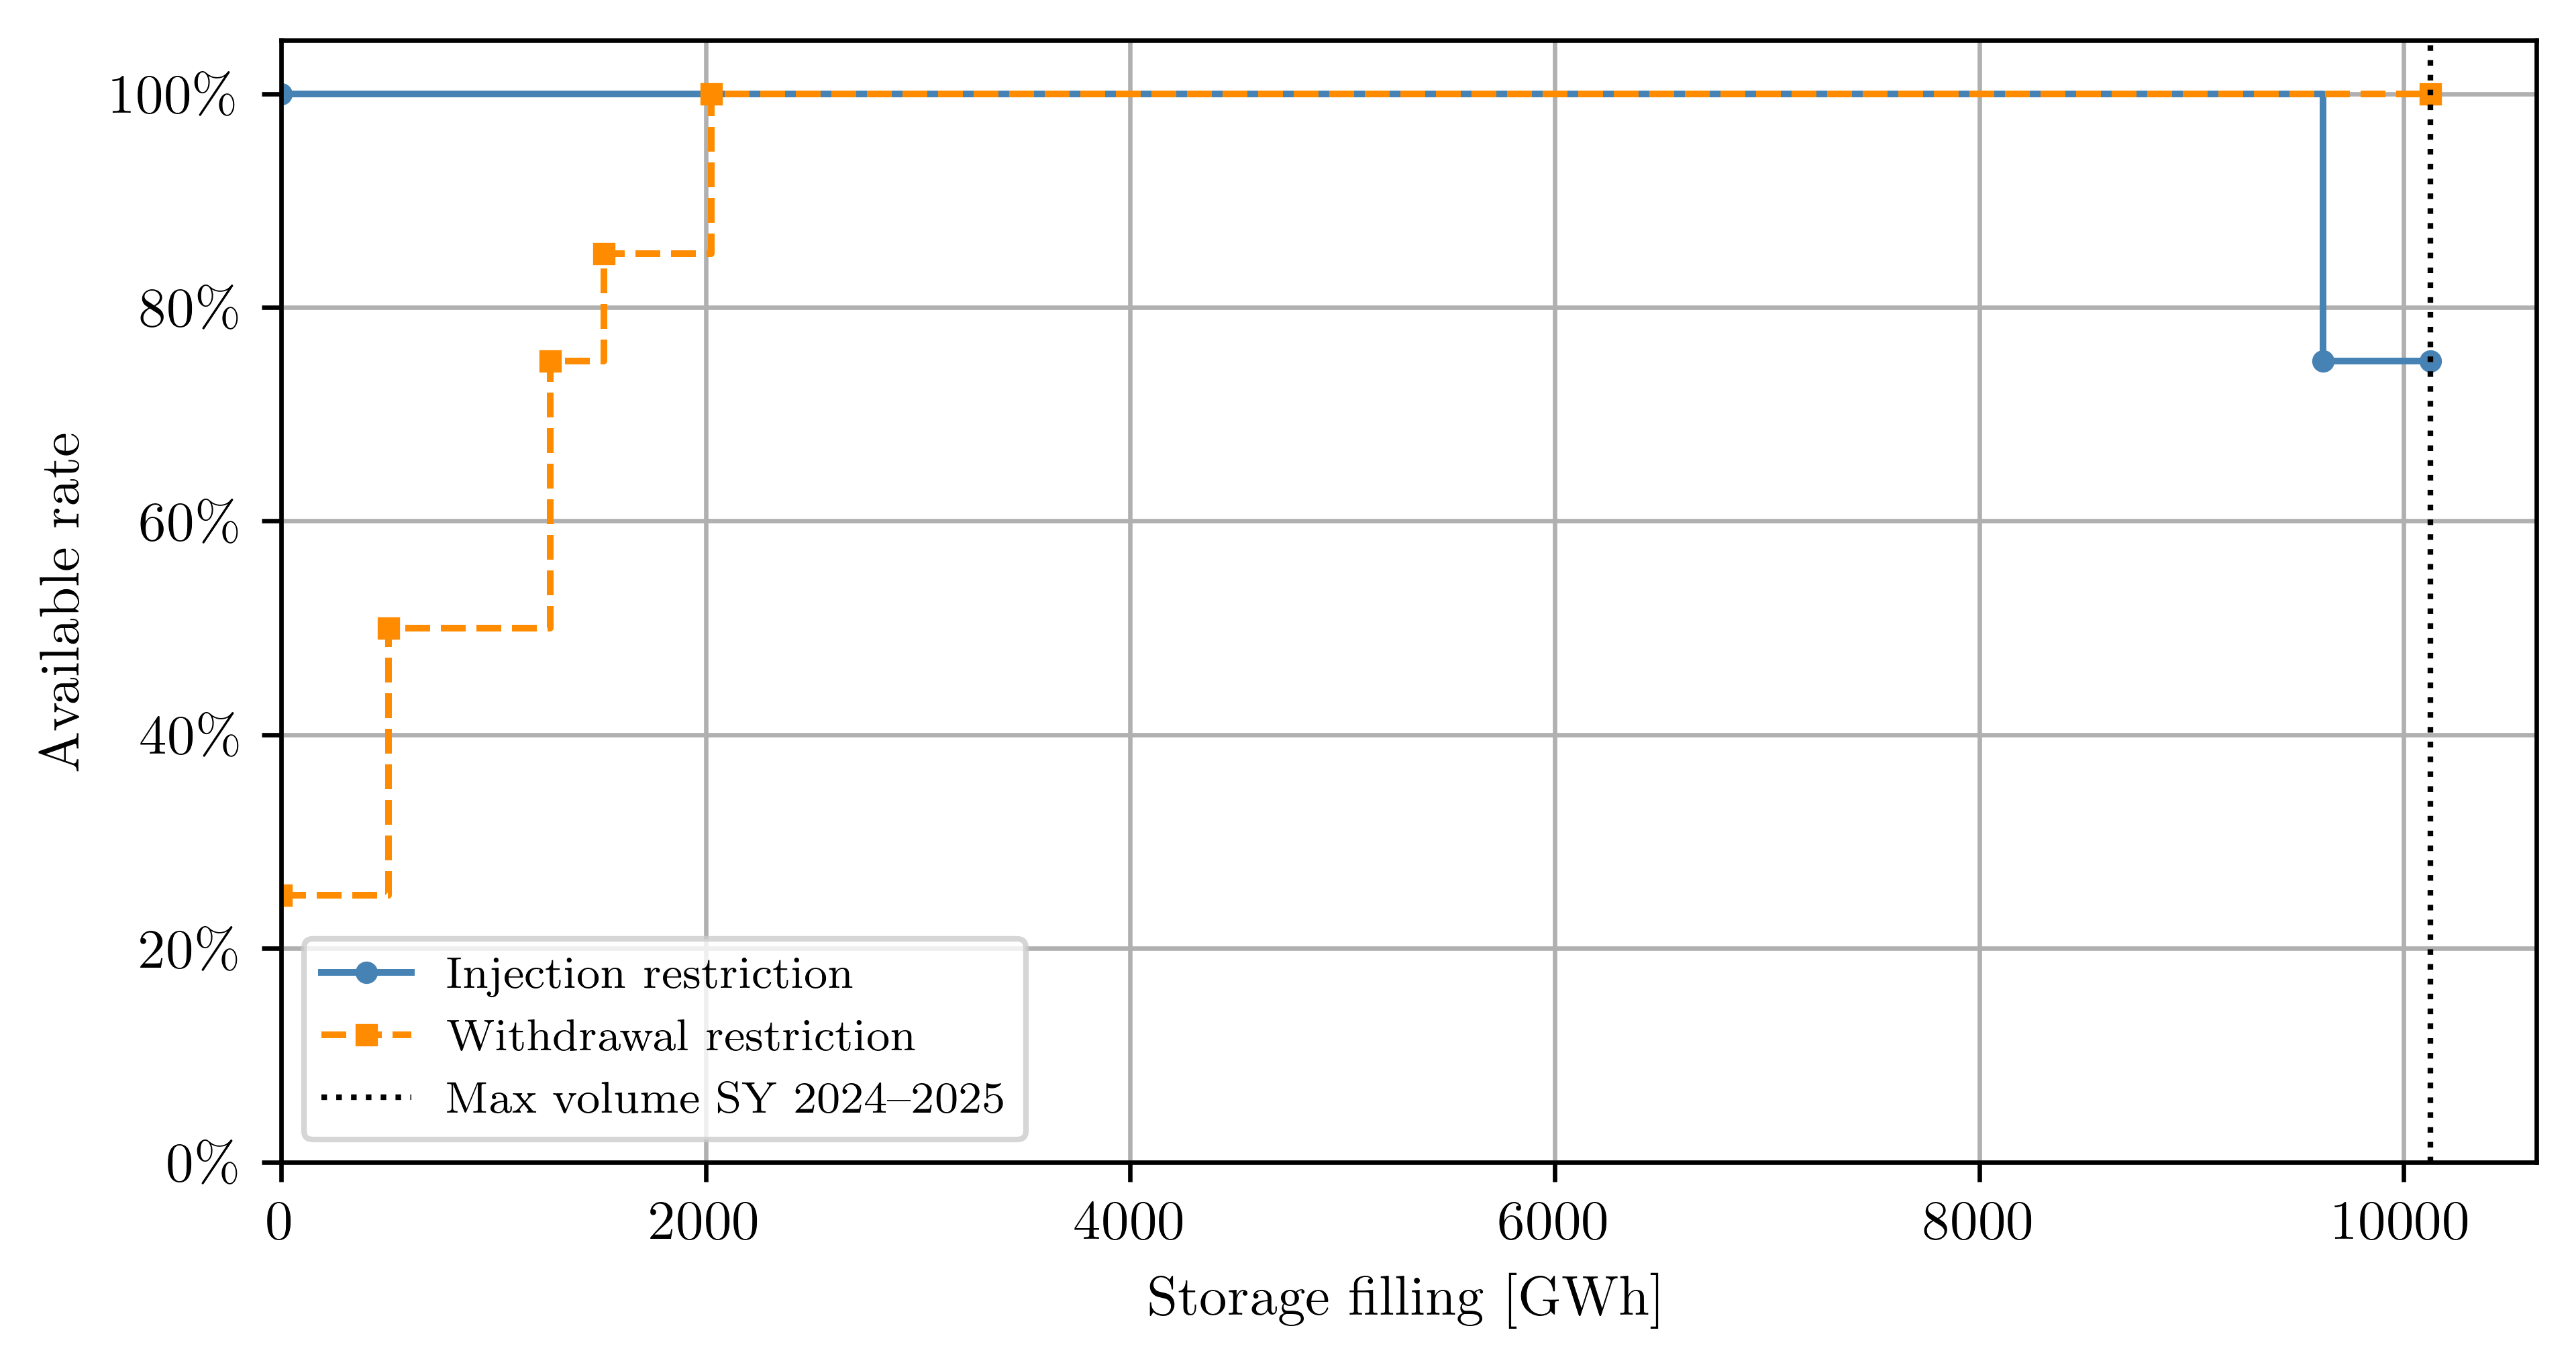

In [8]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Total working gas capacity as of 29/12/2023
max_volume_gwh = 10125

# Fill thresholds converted from percentages to GWh
fill_5 = 0.05 * max_volume_gwh
fill_12_5 = 0.125 * max_volume_gwh
fill_15 = 0.15 * max_volume_gwh
fill_20 = 0.20 * max_volume_gwh
fill_95 = 0.95 * max_volume_gwh

# Stepwise availability profiles from the valuation table
inj_x = np.array([0, fill_95, max_volume_gwh])
inj_y = np.array([100, 75, 75])

wr_x = np.array([0, fill_5, fill_12_5, fill_15, fill_20, max_volume_gwh])
wr_y = np.array([25, 50, 75, 85, 100, 100])

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

ax.step(
    inj_x,
    inj_y,
    where="post",
    color="steelblue",
    linestyle="-",
    marker="o",
    markersize=3,
    lw=1.2,
    label="Injection restriction",
)
ax.step(
    wr_x,
    wr_y,
    where="post",
    color="darkorange",
    linestyle="--",
    marker="s",
    markersize=3,
    lw=1.2,
    label="Withdrawal restriction",
)
ax.axvline(10_125, color="black", linestyle=":", lw=1.0, label="Max volume SY 2024--2025")

ax.set_xlabel("Storage filling [GWh]")
ax.set_ylabel("Available rate")
ax.set_xlim(0, max_volume_gwh + 500)
ax.set_ylim(0, 105)
ax.set_xticks([0, 2000, 4000, 6000, 8000, 10000])
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_yticklabels(["0\\%", "20\\%", "40\\%", "60\\%", "80\\%", "100\\%"])
ax.grid(True)
ax.legend(loc="lower left", fontsize=8)

fig.tight_layout()
plt.savefig("../../fig/Plots/GSD_IR_WR_constraints.png")
plt.show()
